In [ ]:
# Introduction and Motivation for Manual Backpropagation
# • The lecture continues implementation of a multilayer perceptron (MLP) for character-level modeling.
# • The current model uses PyTorch’s loss.backward() for automatic differentiation to calculate gradients.
# • The presenter emphasizes removing autograd and manually implementing the backward pass on tensors for educational and practical debugging benefits.
# • Backpropagation is referred to as a “leaky abstraction”: it doesn’t magically work without understanding its internals; lack of understanding can cause subtle bugs or inefficiencies.
# • Historical context: ~10 years ago, manually writing backward passes was standard practice before autograd engines became ubiquitous.
# • Examples shown from early deep learning papers and code illustrate manual gradient calculations, their complexity, and how autograd simplified the
# process.
# The presenter argues that manual backward implementation deepens understanding, 
#improves debugging skills, and demystifies neural network training.

# The lecture begins with a recap of the current state of the neural network implementation: 
# a two-layer multilayer perceptron (MLP) with batch normalization is trained using PyTorch’s
# automatic differentiation (loss.backward()). Although exciting developments in recurrent neural
# networks (RNNs) and their variants lie ahead, this lecture pauses to focus on a crucial
# foundational exercise: manually implementing the backward pass of the network on the tensor level.
# The instructor argues that relying solely on autograd is a “leaky abstraction,” meaning it 
# can hide critical complexities and failure modes such as dead neurons, exploding/vanishing 
# gradients, and subtle bugs in gradient clipping. Understanding the backward pass thoroughly 
# helps debug and optimize neural networks effectively. The value of this manual approach is 
# reinforced by historical context: before the rise of autograd engines like PyTorch’s, writing
# backward passes by hand was common practice, and many influential papers and projects from 2006
# to 2014 involved manual gradient calculations.
# The notebook for this lecture retains the same forward pass but removes loss.backward(), 
# replacing it with explicit gradient calculations, layer by layer. The goal is to compare
# these manual gradients against PyTorch’s calculations to validate correctness.


#https://karpathy.github.io/neuralnets/
#https://medium.com/@karpathy/yes-you-should-understand-backprop-e2f06eab496b
#https://arxiv.org/pdf/1406.5679

In [14]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [15]:

# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [16]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [17]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [18]:
# ok biolerplate done, now we get to the action:
# Exercise 1: Backpropagation through the Loss and Softmax
# The first exercise involves backpropagating through the loss function broken down 
# into detailed intermediate steps. The forward pass includes explicit computation of logits, 
# numerical stabilization by subtracting the maximum logit per batch example, exponentiation, 
# normalization to probabilities, and then cross-entropy loss calculation.
# The backpropagation starts with calculating the gradient of the loss with respect to the logits
#     (dlogits). The instructor carefully derives how the loss depends on the selected logits
# corresponding to the true labels, showing that the gradient is negative inverse batch size 
# at those positions and zero elsewhere. This gradient is implemented as a tensor of zeros 
# with values set to -1/n at the correct indices, and then validated against PyTorch’s autograd.
# Next, the gradient propagates through the log operation from probabilities to logits, using 
# the derivative of log(x) = 1/x. Then, gradients flow backward through the exponentiation and
# normalization steps, carefully handling broadcasting and summation due to tensor shape 
# mismatches. The lecture covers the subtleties of summing gradients when a tensor is 
# replicated during forward pass broadcasting—highlighting that gradients must be summed 
# over all replicated branches.
# Special attention is given to the numerical stability trick of subtracting max logits, 
# showing that although this operation does not affect probabilities or loss, it contributes
# negligible gradients, almost zero, reflecting its role as a pure numerical safeguard.
# Finally, backpropagation through the logits calculation itself is detailed, including
# the matrix multiplication and bias addition. The instructor breaks down the matrix 
# calculus into small scalar examples, demonstrating how gradients with respect to
# inputs, weights, and biases are matrix multiplications and sums of gradients. This 
# demystifies the backward pass through linear layers. The exercise ends with validation
# of all manually computed gradients against PyTorch’s autograd.



In [19]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [20]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [21]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [22]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True) #mini batch mean 
bndiff = hprebn - bnmeani 
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3179, grad_fn=<NegBackward0>)

In [ ]:
# Review of Existing Implementation and Setup for Manual Backpropagation
# • The MLP model setup remains mostly unchanged: two-layer perceptron with batch 
# normalization.
# • Forward pass is expanded into many intermediate tensors to facilitate manual gradient 
# calculations in the backward pass.
# • A utility function is introduced to compare manually computed gradients with PyTorch’s 
# autograd gradients for verification.
# • Parameter initialization is slightly altered by using small random numbers instead of 
# zeros for biases to unmask potential errors in gradient calculations.
# • The forward pass explicitly implements the loss function instead of using PyTorch’s 
# F.cross_entropy for finer control and gradient propagation.
# • The approach is to compute derivatives for all intermediate tensors, prepending d_ to
#     tensor names to denote gradients of the loss w.r.t. those tensors.
# • Exercise 1 involves fully manual backpropagation through the entire computational graph
#     and verifying correctness against PyTorch gradients.
# • Exercises 2 and 3 will simplify and optimize backward passes for loss and batch 
# normalization using analytical derivations.


# Exercise 1: Manual Backpropagation for Cross-Entropy Loss (Step 1)
# • Starts with calculating d_logprobs: the gradient of the loss with respect to log 
# probabilities (logprobs).
# • Shape of logprobs is [batch_size=32, num_classes=27]. The gradient tensor must be 
# the same shape.
# • Loss is defined as negative mean of the log probability of the correct class for 
# each example.
# • Derivative of loss w.r.t. selected logprobs elements is -1/N (N=batch size); 
# all other elements have zero gradient since they do not affect the loss.
# • Implementation uses a zero tensor of shape [32, 27] and sets the gradient only
# at positions corresponding to the correct labels.
# • The computed gradient matches exactly with PyTorch’s autograd output (verified 
#     by torch.allclose).
# • Next, backpropagates through the log operation from probs to logprobs using the chain rule:
# [
# \frac{\partial \text{loss}}{\partial \text{probs}} 
#     = \frac{\partial \text{loss}}{\partial \logprobs} \times \frac{1}{\text{probs}}
# ]
# • This calculation boosts gradients where predicted probabilities are low
# for the correct class, intuitively focusing learning on incorrectly predicted examples.
# • Verified correctness again against PyTorch gradients.


    

In [24]:
Yb

tensor([ 8, 14, 15, 22,  0, 19,  9, 14,  5,  1, 20,  3,  8, 14, 12,  0, 11,  0,
        26,  9, 25,  0,  1,  1,  7, 18,  9,  3,  5,  9,  0, 18])

In [23]:
logprobs.shape

torch.Size([32, 27])

In [25]:
logprobs

tensor([[-2.5815, -2.4383, -4.0656, -2.9420, -4.0057, -2.5484, -3.8067, -3.3759,
         -4.0131, -3.4631, -3.3218, -3.2753, -3.2477, -3.4758, -3.3829, -4.3370,
         -4.8465, -3.9360, -4.1501, -2.8764, -2.9064, -3.7808, -3.6495, -2.6736,
         -2.9089, -3.6288, -3.8581],
        [-2.8100, -2.8531, -2.4378, -2.9092, -3.3190, -3.4331, -4.0295, -3.1195,
         -3.7739, -3.7125, -2.9871, -3.0565, -3.0176, -3.4736, -3.1138, -3.3821,
         -3.6551, -4.0669, -3.9347, -3.2218, -3.9663, -3.6962, -4.1161, -2.8511,
         -3.8036, -3.2797, -3.6332],
        [-3.9227, -3.6844, -4.2623, -4.3077, -3.7760, -3.2024, -2.8341, -2.8248,
         -2.7778, -3.4706, -3.9490, -3.2737, -3.1289, -2.9854, -3.8318, -3.6619,
         -4.3216, -3.4105, -3.5905, -2.2045, -2.6398, -3.3600, -3.2173, -3.2583,
         -3.2818, -3.9437, -3.5730],
        [-3.3772, -3.5990, -3.2505, -2.8879, -2.8912, -3.5853, -3.1119, -3.1598,
         -2.9795, -4.0156, -3.2519, -3.6619, -3.3118, -3.1501, -2.9022, -2.8260

In [26]:
logprobs[range(n), Yb]



tensor([-4.0131, -3.1138, -3.6619, -3.1746, -4.0219, -3.4758, -3.1193, -4.0818,
        -3.2289, -4.2230, -3.1124, -1.5998, -2.7719, -3.0490, -2.9428, -3.0437,
        -3.7879, -2.8864, -3.5109, -3.3394, -2.8357, -2.8859, -4.2581, -3.9679,
        -3.4839, -2.9712, -2.9748, -3.8804, -2.8916, -3.4609, -3.2271, -3.1768],
       grad_fn=<IndexBackward0>)

In [30]:
counts.shape , counts_sum_inv.shape

(torch.Size([32, 27]), torch.Size([32, 1]))

In [ ]:
# c = a*b , but with tensors 
# a[3X3] * b[3,1] -->
# a11*b1 a12*b1 a13*b1 
# a21*b2 a22*b2 a23*b2
# a31*b3 a32*b3 a33*b3
# c[3X3]
#This part focuses on backpropagating through the count sum and counts operations. 
#It details the shape differences between counts (32x27) and count sum (32x1), 
#explaining PyTorch's broadcasting of the count sum column tensor to match counts for
#element-wise multiplication. The multiplication is broken into two steps: replication 
#of count sum and element-wise multiplication. The local derivative of multiplication with 
#respect to counts is counts itself, while backpropagation through replication requires
#summing gradients across replicated elements. This summation ensures gradients match 
#the original tensor shape.


In [37]:
dlogit_maxes

tensor([[ 3.7253e-09],
        [ 9.3132e-10],
        [-3.7253e-09],
        [ 6.9849e-10],
        [ 2.7940e-09],
        [ 0.0000e+00],
        [-1.3970e-09],
        [-4.6566e-10],
        [-9.3132e-10],
        [ 4.8894e-09],
        [-2.3283e-09],
        [-4.6566e-10],
        [-5.3551e-09],
        [ 3.0268e-09],
        [-5.5879e-09],
        [ 6.9849e-10],
        [ 1.3970e-09],
        [-9.3132e-10],
        [-2.7940e-09],
        [ 1.6298e-09],
        [ 9.3132e-10],
        [ 3.2596e-09],
        [-3.2596e-09],
        [-1.1642e-09],
        [ 1.8626e-09],
        [-3.2596e-09],
        [-5.1223e-09],
        [-1.8626e-09],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [-4.6566e-10],
        [ 2.3283e-09]], grad_fn=<SumBackward1>)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0


counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0


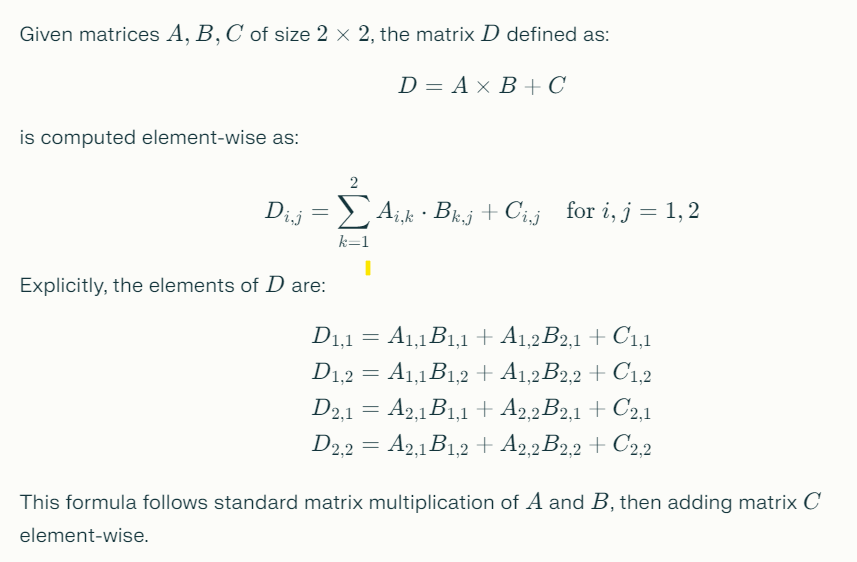

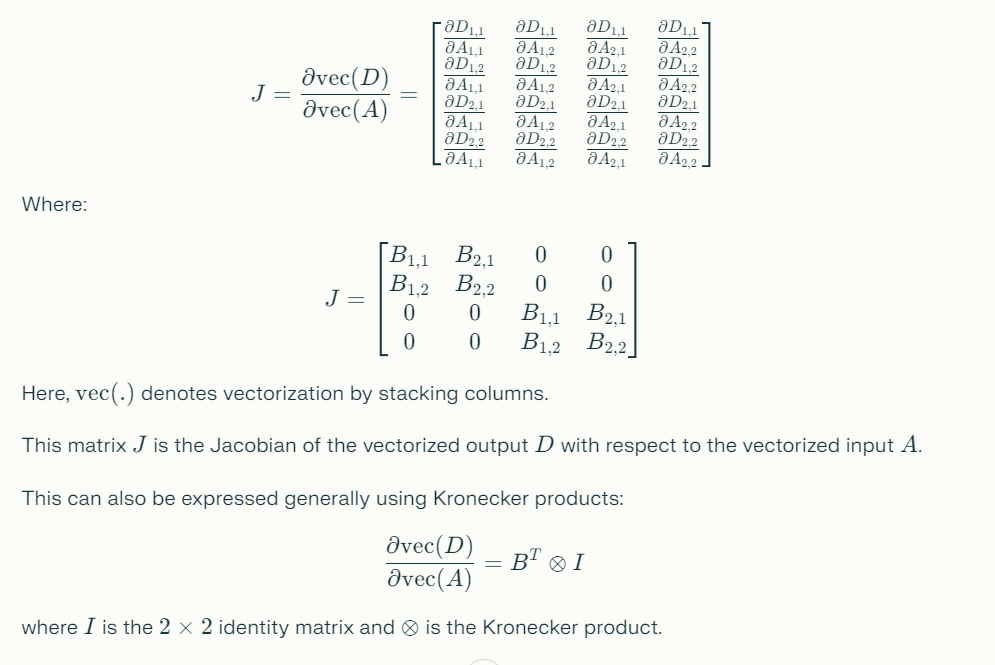

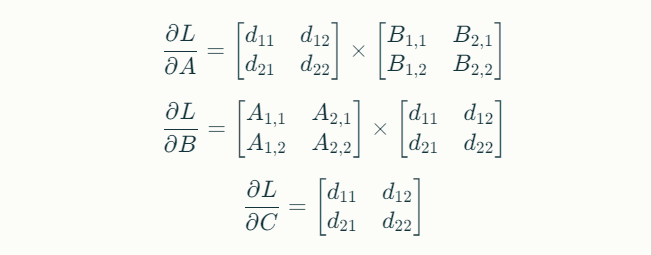

h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0


hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff: 0.0
bnvar_inv       | exact: True  | approximate: True  | maxdiff: 0.0
bnvar           | exact: True  | approximate: True  | maxdiff: 0.0
bndiff2         | exact: True  | approximate: True  | maxdiff: 0.0
bndiff          | exact: True  | approximate: True  | maxdiff: 0.0
bnmeani         | exact: True  | approximate: True  | maxdiff: 0.0
hprebn          | exact: True  | approximate: True  | maxdiff: 0.0
embcat          | exact: True  | approximate: True  | maxdiff: 0.0
W1              | exact: True  | approximate: True  | maxdiff: 0.0
b1              | exact: True  | approximate: True  | maxdiff: 0.0
emb             | exact: True  | approximate: True  | maxdiff: 0.0
C               | exact: True  | approximate: True  | maxdiff:

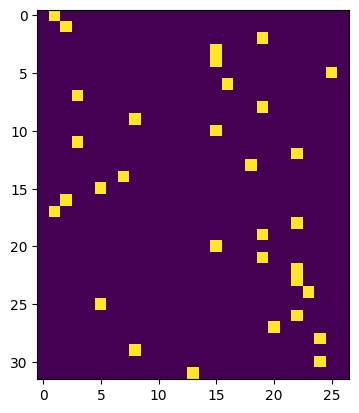

In [69]:

# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one

#loss = -(a+b+c)/3
#dloss/da = -1/3 = -1/n
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
cmp('logprobs', dlogprobs, logprobs)
dprobs = (1.0 / probs) * dlogprobs
cmp('probs', dprobs, probs)


# logits = xenc @ W 
# counts = logits.exp()
# probs = counts / counts.sum(1, keepdims=True)
# probs

dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)


#The explanation continues on backpropagation through replication, 
#comparing it to a micrograd example where a node output feeds multiple branches. 
#The correct backpropagation sums gradients from all uses of the replicated variable. 
#Here, summing horizontally across columns retains the 32x1 shape of count sum gradients. 
#The implementation matches expected results, confirming correctness. The segment then 
#moves to backpropagation into counts, stating that the derivative of counts is count
#sum and the chain rule applies with broadcasting for multiplication.


dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv

from IPython.display import Image, display
display(Image(url='https://www.imathist.com/wp-content/uploads/2023/08/Derivative-of-1x-by-first-principle.webp', width=1900, unconfined=True))
#https://www.imathist.com/wp-content/uploads/2023/08/Derivative-of-1x-by-first-principle.webp
cmp('counts_sum', dcounts_sum, counts_sum)

#The segment discusses the complexity of backpropagating through counts, 
#which is used twice: directly and through count sum. It emphasizes the need 
#to complete the second branch involving count sum because count sum depends on counts. 
#The derivative of count sum is derived using the power rule for negative exponents, 
#resulting in a local derivative of negative count sum to the negative two, multiplied 
#by the upstream gradient. This derivative is verified for correctness and shape consistency.





# a11 a12 a13 --> b1 (= a11 + a12 + a13)
# a21 a22 a23 --> b2 (= a21 + a22 + a23)
# a31 a32 a33 --> b3 (= a31 + a32 + a33)
dcounts += torch.ones_like(counts) * dcounts_sum
cmp('counts', dcounts, counts)


#Here, backpropagation through the summation operation converting counts (32x27)
#to count sum (32x1) is analyzed. The local derivative for sum is 1 for elements that 
#contribute to the sum and 0 elsewhere, meaning gradients from count sum are routed 
#equally back to the corresponding counts elements. This routing effectively replicates
#the count sum gradient horizontally across the counts dimensions. The segment details 
#implementing this replication via broadcasting using a tensor of ones, ensuring correct 
#gradient shapes. It also stresses adding gradients from multiple branches to form the final 
#counts gradient, with validation against PyTorch's results.

#counts = norm_logits.exp()
dnorm_logits = counts * dcounts
cmp('norm_logits', dnorm_logits, norm_logits)



#The final part covers backpropagation through the normalization of logits to counts. 
#Since the operation is element-wise exponentiation, the local derivative is the 
#exponentiated value itself, which is counts. The gradient is then counts multiplied 
#by the upstream gradient. This derivative is verified and matches expected results, 
#completing the detailed walkthrough of backpropagation through the log, count sum, 
#and counts operations involved in probability normalization.


#norm_logits = logits - logit_maxes # subtract max for numerical stability
#c11 c12 c13 = a11 a12 a13   b1
#c21 c22 c23 = a21 a22 a23 - b2
#c31 c32 c33 = a31 a32 a33   b3 
#so e.g c32 = a32 - b3 

#The segment explains backpropagation through operations involving tensors with broadcasting,
#focusing on the subtraction of logits and logit maxes. It clarifies how derivatives flow 
#when shapes differ, specifically that each element’s derivative with respect to inputs 
#follows the broadcasting rules. The gradients for broadcasted tensors require summation 
#along the broadcasted dimensions, and negative signs from the subtraction affect the 
#gradient signs. Implementation details include cloning tensors for safety and summing 
#gradients properly to match shapes while noting that the current gradients calculated 
#are partial since logits receive gradient signals from multiple branches.


dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
cmp('logit_maxes', dlogit_maxes, logit_maxes)








#This segment discusses the role of logit maxes in numerical stability of the softmax function,
#explaining that adding or subtracting the max logit from all logits in a row does not change
#the softmax output or loss. Therefore, gradients with respect to the logit maxes are expected
#to be zero or very close to zero, which is confirmed empirically with very small 
#floating-point values. It highlights that while this backward propagation branch may 
#seem unnecessary, breaking down computations confirms that the small gradients correctly 
#reflect the non-impact of logit maxes on the loss.

#The focus shifts to backpropagation through the 
#second branch involving the max operation on logits.
#The forward pass returns both max values and their indices,
#which are crucial for the backward pass. The gradient flowing back through the 
#max operation involves scattering the gradient from the max values back into the 
#corresponding positions in the original logits tensor. The segment shows how this
#can be implemented efficiently using one-hot encoding of indices and element-wise 
#multiplication with the gradient column vector, ensuring correct gradient routing 
#for each maximum element.

dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
plt.imshow(F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]))
dlogit_maxes.shape
cmp('logits', dlogits, logits)



#Attention turns to backpropagation through a linear layer where logits are computed as a
#matrix multiplication of hidden states and a weight matrix plus a bias vector. 
#The segment explains the shapes of all involved tensors, describing how broadcasting works 
#for the bias addition. It then introduces the approach to derive gradients for matrix
#multiplication from first principles by analyzing a small 2x2 example, breaking down 
#matrix multiplication into scalar multiplications and additions. This decomposition 
#makes it clear how the chain rule applies to each element and how gradients flow through 
#such linear algebra operations.


#logits = h @ W2 + b2 # output layer
#d = a * b + c

from IPython.display import Image, display
display(Image(filename='Matrix1.png'))

#Building on the small example, the speaker derives gradients for each element of the input 
#matrices by applying the chain rule to every scalar multiplication and addition. It is shown 
#that an element in one matrix can affect multiple outputs, so gradients sum contributions 
#from all affected outputs. The result is that the gradient with respect to the first input 
#matrix can be expressed as a matrix multiplication of the output gradient and the transpose 
#of the second matrix. Similarly, the gradient with respect to the second input matrix is the
#transpose of the first matrix multiplied by the output gradient. The bias gradients are sums 
#of the output gradients across rows, illustrating that the backward pass for matrix 
#multiplication plus bias is also expressed via matrix multiplications and summations.


display(Image(filename='dlda.png'))
display(Image(filename='lossderivative.png'))

# The segment summarizes the backward pass formulas for matrix multiplication and 
# bias addition, emphasizing that they reduce to matrix multiplications and sums 
# without requiring memorization of formulas. The speaker reveals a practical tip:
# reasoning about tensor shapes ensures the correctness of gradient computations. 
#     By knowing the shapes of inputs and outputs, one can deduce the necessary
# matrix multiplications for gradients. This approach is demonstrated with concrete
#     tensor shapes, showing how to derive the correct transpositions and                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
# summations needed for backpropagation through linear layers.

#T(tranpose)

dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)


# Using the shape reasoning approach, the speaker derives the gradients with respect to 
# the hidden states, the weight matrix, and the bias vector for the linear layer. For 
# the hidden states, the gradient is obtained by multiplying the output gradient with the
# transpose of the weight matrix. For the weight matrix, the gradient is computed by
# multiplying the transpose of hidden states with the output gradient. The bias gradient is 
# given by summing the output gradients along the batch dimension. The segment ends by showing 
# how these operations are implemented in code, illustrating that understanding tensor
# shapes guides 
# the correct formulation of backpropagation without memorizing explicit formulas.

cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)


#The segment begins with verifying the correctness of derivatives through a linear 
#layer using backpropagation. It then moves on to deriving the gradient through the 
#tanh activation function (10h), explaining that the derivative can be simplified to one minus
#the square of the output of tanh, rather than its input. This simplification is 
#supported by a Google image search and mathematical derivation, emphasizing the 
#chain rule application to get the local derivative for backpropagation.

display(Image(url='https://th.bing.com/th/id/R.e809705f3dc5b34e7a188cef14bb9fed?rik=X1adLYe7%2bXtCYw&riu=http%3a%2f%2fronny.rest%2fmedia%2fblog%2f2017%2f2017_08_16_tanh%2ftanh_and_derivative_formulas.jpg&ehk=bFJbyA3abtACDAh6b5jnkg14TVEv4jsDFlg4fJS1arc%3d&risl=&pid=ImgRaw&r=0&sres=1&sresct=1', width=1900, unconfined=True))

dhpreact = (1.0 - h**2) * dh
cmp('hpreact', dhpreact, hpreact)




# Backpropagation through batch normalization parameters, specifically the gain (BN gain) and
# bias (BN bias), is discussed. The distinction between element-wise multiplication and
# matrix multiplication is clarified, with attention to the broadcasting of parameters
# shapes during operations. The importance of correctly summing gradients across
# replicated dimensions due to broadcasting is emphasized to ensure proper gradient flow.
#hpreact = bngain * bnraw + bnbias
#bngain * bnraw = hpreact-bnbias
#bngain = hpreact-bnbias *(bnraw ** -1)
#bngain = hpreact*bnraw ** -1  - bnbias*bnraw **-1
#dbngain = dhreact(bnraw-1) + 0 - 0 -0 


dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)

#The explanation continues on how to compute gradients for BN gain and BN bias by summing 
#across the batch dimension due to their shape (1 by 64) being broadcasted to match input 
#dimensions (32 by 64). The speaker admits uncertainty about why BN gain and BN bias were 
#designed as two-dimensional tensors but stresses the importance of consistent shapes for 
#gradient correctness. The calculation for the gradient of BN raw (the normalized input) is
#also covered, showing how BN gain multiplies the upstream gradient.


#The segment explains gradient backpropagation for the BN bias, which sums gradients 
#across the batch dimension similar to BN gain. It then transitions to the batch 
#normalization process itself, breaking it into manageable pieces: mean, difference
#from mean, variance, and normalization steps. The speaker notes a deliberate choice 
#to normalize variance using one over n minus one (unbiased estimator) instead of one 
#over n, explaining the use of the epsilon term for numerical stability, and introduces variables for these calculations.

# BatchNorm layer
# bnmeani = 1/n*hprebn.sum(0, keepdim=True) #mini batch mean 
# bndiff = hprebn - bnmeani 
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# • Batch norm forward pass broken down into atomic operations with shapes tracked carefully:
# • Compute mean (\mu) and variance (\sigma^2) (with Bessel’s correction: dividing by (n-1)
# instead of (n)) for unbiased variance estimate.
# • Subtract mean and normalize input.
# • Multiply by gain and add bias (handled previously).
# • Backpropagation through each step involves:
# • Chain rule applied to element-wise multiplications and sums, with broadcasting
#     and summation handled carefully.
# • Dual branches of gradients due to dependencies of variance and mean on input, 
#     requiring summation of multiple gradient contributions.
# • The presenter emphasizes the importance of using the unbiased variance estimator 
#     (dividing by (n-1)) for batch norm, pointing out that the original paper uses biased 
#     variance for training but unbiased for inference, which can cause train-test mismatches.
# • The presenter prefers consistent use of unbiased variance to avoid these issues.
# • Verifications against PyTorch gradients confirm correctness of partial backward steps.
# The backward pass is partially completed here, with some gradient terms pending.

# Backpropagation through the batch normalization normalization step is discussed in detail,
# focusing on how to propagate gradients through the variance and normalized values. 
#     The speaker highlights the need to carefully handle broadcasting due to differing
#     tensor shapes and how to sum gradients appropriately across batch dimensions.
#         It is noted that the gradient for B and diff (difference from mean) is
# incomplete at this stage, 
# as it branches into multiple paths needing further backpropagation.
#################


dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)


dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
cmp('bnvar', dbnvar, bnvar)

# The speaker continues implementing and verifying the backpropagation for batch normalization,
# emphasizing the correct handling of broadcasting and summing gradients across batch 
# dimensions to maintain shape integrity. They also verify gradient correctness with a 
# check function, which can detect incorrect gradients. The power rule is applied to 
# differentiate the term raised to the negative 0.5 power (inverse square root), 
# leading to the candidate derivative formula, which is tested and confirmed correct.


#https://math.oxford.emory.edu/site/math117/besselCorrection/
# A detailed discussion about the choice between biased and unbiased variance estimators in 
# batch normalization is presented. The speaker explains that the unbiased estimator 
# (dividing by n minus one) is preferred because it provides a better variance estimate 
#     for small sample sizes like mini-batches. They criticize the original paper's 
#     inconsistency of using biased estimation in training and unbiased in inference, 
# calling it a train-test mismatch considered a bug. The speaker prefers consistently
# using the unbiased estimator during both training and inference.



#The segment dives deeper into the gradient backpropagation through batch normalization,
#focusing on the implications of sums and broadcasting in forward and backward passes.
#The duality concept is explained: sums in forward pass correspond to broadcasting in 
#backward pass and vice versa. To clarify, a toy example with a 2x2 matrix is considered 
#for understanding how gradients flow through sum and scaling operations. The speaker 
#outlines constructing the gradient using broadcasting and multiplication in PyTorch.
#bndiff = hprebn - bnmeani 
#bndiff2 = bndiff**2

dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
dbndiff += (2*bndiff) * dbndiff2
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)

#Further backpropagation steps for batch normalization are covered, focusing on 
#differentiating through element-wise square operations and correctly summing gradients
#from multiple branches. The speaker emphasizes the importance of adding gradients when
#multiple computational paths merge. They demonstrate handling broadcasting when subtracting 
#batch means and show how gradients are scaled and summed over the batch dimension. 
#The process highlights careful shape management and the need for cloning tensors to avoid
#unintended in-place operations.



#Backpropagation through batch normalization continues with handling the gradient flow 
#through broadcasted parameters and sums. The speaker demonstrates how to multiply 
#gradients by constants (like 1/n) and replicate these gradients across batch dimensions 
#using broadcasting in PyTorch. They verify the implementation, noting expected incorrectness
#at intermediate steps due to incomplete gradient paths. The segment prepares for completing 
#the backpropagation of batch normalization by handling all branches of the computational graph.

#bndiff = hprebn - bnmeani 
## bnmeani = 1/n*hprebn.sum(0, keepdim=True) #mini batch mean 

dhprebn = dbndiff.clone()#incorrect

#dbnmeani = (-torch.ones_like(bndiff)*dbndiff).sum(0)
#dbnmeani =(-dbndiff).sum(0)

dbnmeani = (-dbndiff).sum(0)
cmp('bnmeani', dbnmeani, bnmeani)





#bnmeani = 1/n*hprebn.sum(0, keepdim=True) 



dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)
cmp('hprebn', dhprebn, hprebn)



#The process of backpropagating through a linear layer is explained. 
#The shapes of involved tensors are matched to determine appropriate matrix multiplications: 
#the upstream gradient is multiplied by the transpose of the weight matrix to get the input 
#gradient, and the gradient with respect to the bias is computed by summing over the batch
#dimension. The speaker comments on the relative simplicity of backpropagating through linear
#layers and tests the correctness of these derivatives.
#hprebn = embcat @ W1 + b1 


dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)


#Backpropagation through the reshaping (view) operation following concatenation is discussed.
#Since view operations only change the tensor representation without altering data, 
#the backward pass simply involves reinterpreting the gradient tensor with the original shape.
#This allows undoing the concatenation operation by converting the flattened gradient back to 
#its three-dimensional form, ensuring proper gradient flow through the earlier concatenation 
#step.

#emb = C[Xb] # embed the characters into vectors
#embcat = emb.view(emb.shape[0], -1)

demb = dembcat.view(emb.shape)


cmp('emb', demb, emb)


#The final backpropagation step involves undoing an indexing operation that selects
#character embeddings from a lookup table. The forward pass involved extracting rows 
#from a character embedding matrix based on indices representing characters, resulting
#in a 32 by 3 by 10 tensor. In the backward pass, gradients need to be routed back to 
#the correct rows of the embedding matrix, summing gradients for any rows used multiple
#times. Since vectorized solutions are unclear, the speaker uses nested for loops to iterate 
#over batch and character indices to accumulate gradients properly.
#print(emb.shape, C.shape , xb.shape)
#print(Xb[:5])
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix = Xb[k,j]
    dC[ix] += demb[k,j]
    
cmp('C', dC, C)


#The explanation continues the for-loop approach to backpropagate gradients through the 
#embedding lookup. For each example and character position, the gradient slice is added 
#to the corresponding embedding row in the gradient tensor. This accounts for repeated use
#of the same embedding rows by summing gradients appropriately. The speaker concludes this
#step by verifying that the backpropagation through the entire model, including the embedding 
#lookup, works correctly and acknowledges that the first exercise involved more backpropagation
#detail than necessary.










In [43]:
dlogits.shape, h.shape , W2.shape , b2.shape

(torch.Size([32, 27]),
 torch.Size([32, 64]),
 torch.Size([64, 27]),
 torch.Size([27]))

In [70]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())


#The speaker explains that manually breaking down loss calculation into atomic parts for 
#backpropagation is less efficient than using the mathematical expression of the loss directly.
#By differentiating the loss formula analytically, many terms simplify, enabling a faster 
#and more compact implementation. This approach is demonstrated with cross-entropy loss
#in PyTorch, where a single function call computes the loss and gradients efficiently,
#bypassing the need to backpropagate through multiple small operations.

3.3178927898406982 diff: 4.76837158203125e-07


logits          | exact: False | approximate: True  | maxdiff: 5.587935447692871e-09


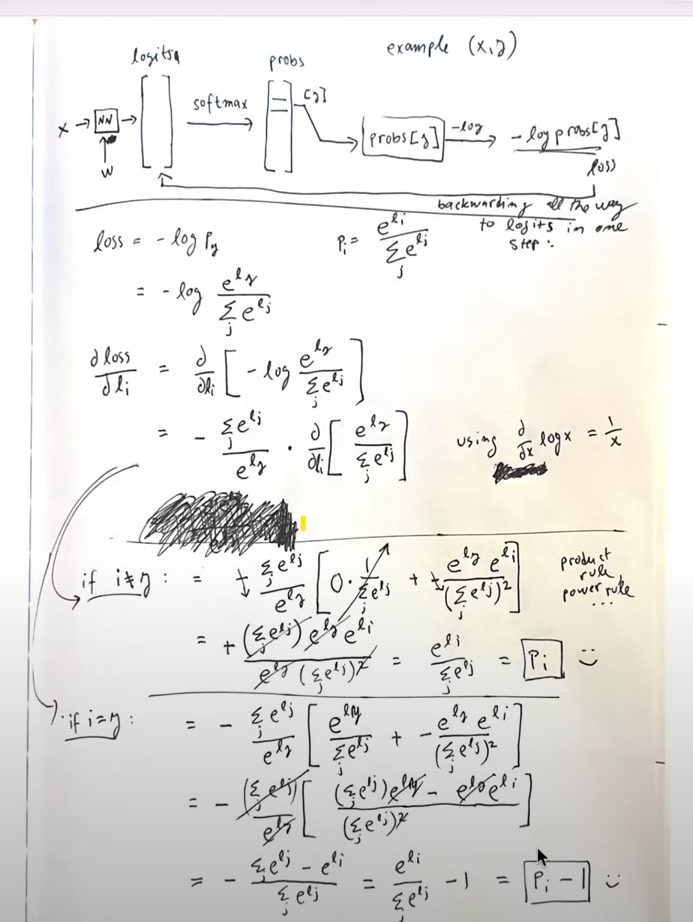

In [73]:
# backward pass

dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

from IPython.display import Image, display
display(Image(filename='softmax.png'))

#The discussion continues with a mathematical explanation of cross-entropy loss involving 
#logits and softmax probabilities. The loss for a single example is framed as the negative 
#log probability of the correct class. The speaker encourages deriving the gradient of this 
#loss with respect to logits by hand, outlining the steps involving softmax and the sum over
#exponentials of logits. This sets up the stage for implementing a more efficient backward pass.

#The speaker presents the analytical gradient of cross-entropy loss with respect to logits,
# which simplifies to the softmax probabilities minus an indicator for the correct class.
#     This gradient is computed for batches by averaging over individual examples.
#     The implementation details include applying softmax along the correct dimension and 
# subtracting one at the indices of the correct labels, then scaling gradients by the batch size.
#         Numerical verification shows very small differences compared to PyTorch's 
#         built-in gradients, attributed to floating-point precision.

# An intuitive interpretation of the logits gradient is given through visualization, 
# showing that the gradient values sum to zero per example. The gradient acts as a
# force: pulling down probabilities of incorrect classes and pushing up the correct one.
#     This balanced push-pull mechanism is likened to a pulley system that ultimately
# adjusts the neural network parameters during training. The strength of the gradient
# corresponds to the confidence of mispredictions, illustrating how the cross-entropy
# loss dynamically guides learning.



In [79]:
logits.shape, Yb.shape

# # • Recognizes that the detailed backward pass through all atomic operations of the 
# loss is tedious and inefficient.
# # • Proposes to derive a closed-form expression for the gradient of the loss
# w.r.t. logits analytically using calculus and simplify it.
# # • Cross-entropy loss for a single example:
# # [
# # \text{loss} = -\log p_y, \quad p_y = \frac{e^{l_y}}{\sum_j e^{l_j}}
# # ]
# # • Derivation shows that gradient w.r.t. logits (l_i) is:
# # [
# # \frac{\partial \text{loss}}{\partial l_i} = p_i - \mathbf{1}{i=y}
# # ]
# # where (p_i) is the softmax probability for class (i), and (\mathbf{1}{i=y}) 
# is 1 if (i) is the correct class, else 0.
# # • For batch size (N), scale by (\frac{1}{N}) to account for mean loss.
# # • Implementation uses PyTorch’s softmax function, subtracts 1 at the correct 
#     label positions, and divides by batch size.
# # • Verified approximate equality with autograd gradients (tiny floating-point differences).
# # • Intuitive interpretation: gradients “push down” probabilities of incorrect 
#     classes and “pull up” the correct class, proportional to predicted probabilities; 
# sum of gradients per example is zero.


(torch.Size([32, 27]), torch.Size([32]))

In [80]:
F.softmax(logits, 1)[0]

tensor([0.0757, 0.0873, 0.0172, 0.0528, 0.0182, 0.0782, 0.0222, 0.0342, 0.0181,
        0.0313, 0.0361, 0.0378, 0.0389, 0.0309, 0.0339, 0.0131, 0.0079, 0.0195,
        0.0158, 0.0563, 0.0547, 0.0228, 0.0260, 0.0690, 0.0545, 0.0265, 0.0211],
       grad_fn=<SelectBackward0>)

In [81]:
dlogits[0] * n

tensor([ 0.0757,  0.0873,  0.0172,  0.0528,  0.0182,  0.0782,  0.0222,  0.0342,
        -0.9819,  0.0313,  0.0361,  0.0378,  0.0389,  0.0309,  0.0339,  0.0131,
         0.0079,  0.0195,  0.0158,  0.0563,  0.0547,  0.0228,  0.0260,  0.0690,
         0.0545,  0.0265,  0.0211], grad_fn=<MulBackward0>)

In [82]:

dlogits[0].sum()

tensor(1.3970e-09, grad_fn=<SumBackward0>)

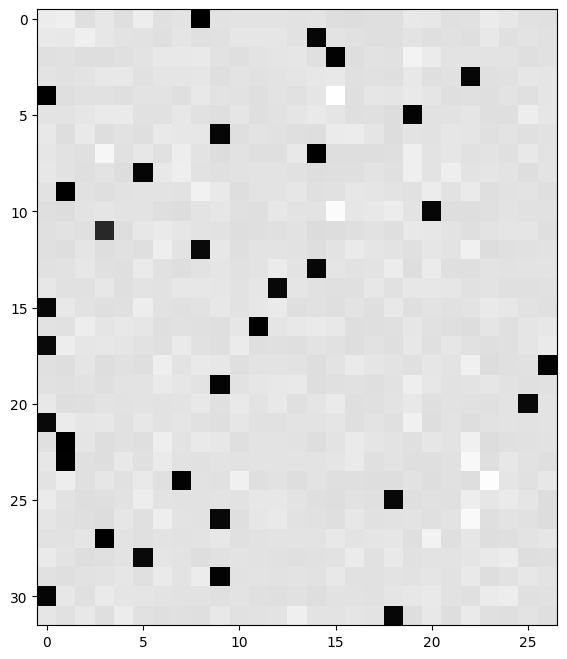

In [84]:

plt.figure(figsize=(8, 8))
plt.imshow(dlogits.detach(), cmap='gray')

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


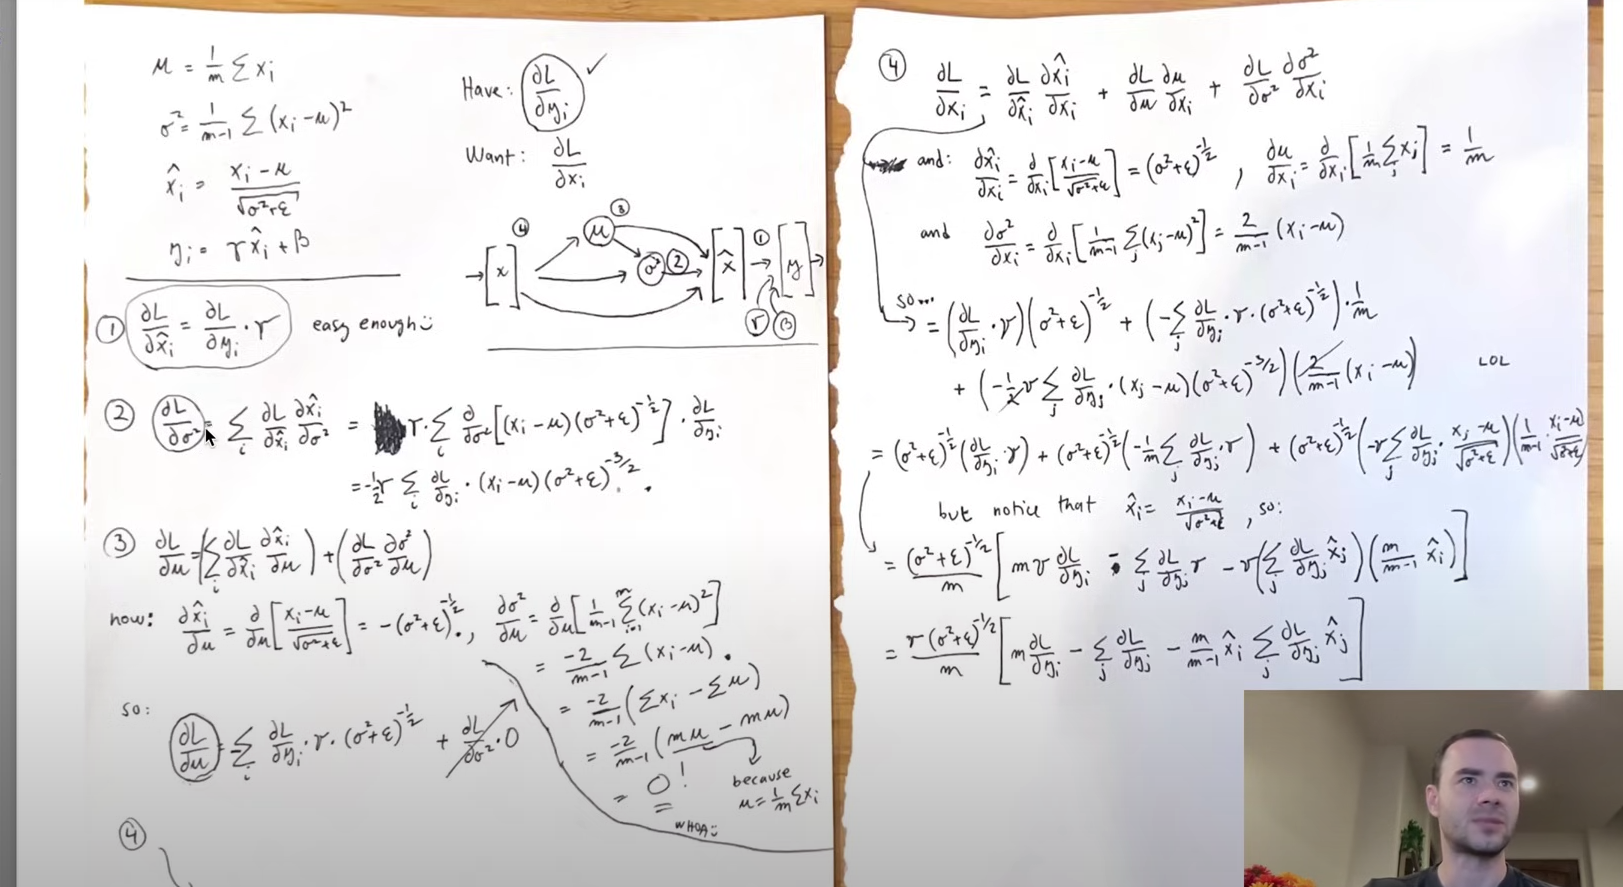

In [88]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())


#The lecture transitions to batch normalization, aiming to derive a simplified backward 
#pass formula similar to what was done for cross-entropy loss. Previously, 
#batch normalization was decomposed into many small operations with backpropagation 
#applied step-by-step. Now, the goal is to treat batch normalization as a single operation 
#and analytically compute its backward gradient. The setup involves calculating derivatives 
#through the batch normalization computation graph, focusing on the hidden pre-activation 
#states and ignoring gamma and beta parameters for simplicity.


#The speaker details the batch normalization backward pass starting from the derivatives 
#of the loss with respect to the outputs of batch normalization. They emphasize the importance
#of understanding that some variables like mean and variance are scalars, while others are 
#vectors. A suggested order for backpropagation is given: from the normalized inputs (X hat) 
#to variance, mean, and finally the original inputs (X). The first step involves multiplying 
#the loss gradients by gamma to get gradients with respect to normalized inputs.


#The derivation of the gradient with respect to variance (sigma squared) is explained,
#highlighting that variance influences all normalized inputs, requiring summation over
#the batch. This involves applying the chain rule across multiple paths in the computation
#graph. The speaker simplifies the resulting expression and notes it will be used for
#subsequent backpropagation steps into mean and original inp  uts.

#Next, the gradient with respect to the mean (mu) is derived. Since the mean affects all 
# normalized inputs and variance, multiple gradient paths must be summed. The speaker points 
# out an interesting case where, because the mean is the batch average, a term involving the
# derivative of variance with respect to mean cancels out, simplifying the expression for
# the mean gradient.

#The final and most complex step is deriving the gradient with respect to the original inputs 
# (X). Each input affects the mean, variance, and normalized input, so three gradient components
# are summed per element. The speaker stresses careful bookkeeping with indices to avoid
# confusion during substitution and summation, renaming variables as needed to maintain clarity.

#The speaker discusses plugging all terms together to form a comprehensive formula for the 
# gradient with respect to inputs. This results in a large, complex expression involving sums 
# and broadcasting operations. Despite its complexity, the formula ultimately simplifies to a 
# manageable form that depends only on quantities available from the forward pass and previously
# computed gradients, enabling efficient vectorized implementation across all neurons and batch
# examples.

from IPython.display import Image, display
display(Image(filename='backnorm.png'))

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


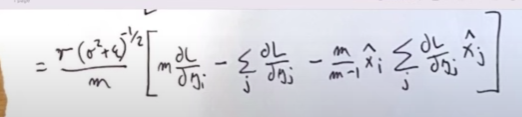

In [90]:

# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

from IPython.display import Image, display
display(Image(filename='dhprebn.png'))

#The derived batch normalization backward formula is implemented in code as a single line, 
#achieving minimal numerical difference compared to PyTorch's automatic differentiation.
#The speaker emphasizes the non-trivial nature of deriving and implementing this formula,
#noting the need to handle multiple neurons and batch elements in parallel while ensuring
#correct broadcasting. The successful verification against PyTorch provides confidence in
#the correctness of the manual implementation.


# • Goal: derive a single closed-form formula for the backward pass of batch normalization 
#rather than backpropagating through all intermediate steps.
# • The presenter sketches the computational graph with variables:
# • Inputs (x_i), mean (\mu), variance (\sigma^2), normalized inputs (\hat{x}_i), 
#output (y_i = \gamma \hat{x}_i + \beta), and gradients (dL/dy_i).
# • Derives gradients in the order:
# 1. (dL/d\hat{x}) via chain rule from (dL/dy).
# 2. (dL/d\sigma^2) considering all paths from (\sigma^2) to each (\hat{x}_i) (sum over batch).
# 3. (dL/d\mu) similarly summing over batch.
# 4. (dL/dx_i) combining derivatives through (\hat{x}_i), (\mu), and (\sigma^2).
# • Takes care to distinguish scalars ((\mu, \sigma^2)) and vectors ((x, \hat{x}, y)) 
#and multiple gradient paths.
# • Final expression for (dL/dx_i) involves sums over batch and terms with (\hat{x}_i),
#(\mu), (\sigma^2), and gradients (dL/dy_i).
# • Presenter implements the formula efficiently using vectorized tensor operations,
#broadcasting, and sums for all neurons and batch samples in parallel.
# • Verifies the implementation matches PyTorch’s autograd gradients with tiny numerical
#differences.
# • Notes the complexity and non-triviality of this derivation and encourages careful study.




In [94]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass


#• The entire MLP model is re-initialized.
# • The manual backward pass implementations for cross-entropy loss and batch normalization
# are combined with previously derived backward passes for linear layers, activations, and
# embedding layers.
# • The training loop is modified to:
# • Disable PyTorch autograd (with torch.no_grad()), removing calls to loss.backward() 
# and usage of .grad attributes.
# • Manually compute gradients for all parameters using custom backward functions.
# • Update parameters using manually computed gradients.
# • The manual backward pass achieves loss and sample quality comparable to the autograd-based
# implementation.
# • The presenter emphasizes the clarity and compactness of the manual backward implementation
# (~20 lines of code) and asserts it provides full visibility into gradient flow.
# • Encourages viewers to appreciate the relative simplicity of manual backward passes while
# acknowledging batch normalization backward is the most complex to implement.



# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
#with torch.no_grad():

  # kick off optimization
for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
      p.grad = None
    loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # -----------------
    dC , dW1, db1 , dW2 , db2 , dbngain, dbnbias = None , None , None , None, None, None, None
    grads = [dC, dW1, db1, dW2, db2 , dbngain , dbnbias]
    # dlogits = F.softmax(logits, 1)
    # dlogits[range(n), Yb] -= 1
    # dlogits /= n
    # # 2nd layer backprop
    # dh = dlogits @ W2.T
    # dW2 = h.T @ dlogits
    # db2 = dlogits.sum(0)
    # # tanh
    # dhpreact = (1.0 - h**2) * dh
    # # batchnorm backprop
    # dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    # dbnbias = dhpreact.sum(0, keepdim=True)
    # dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    # # 1st layer
    # dembcat = dhprebn @ W1.T
    # dW1 = embcat.T @ dhprebn
    # db1 = dhprebn.sum(0)
    # # embedding
    # demb = dembcat.view(emb.shape)
    # dC = torch.zeros_like(C)
    # for k in range(Xb.shape[0]):
    #   for j in range(Xb.shape[1]):
    #     ix = Xb[k,j]
    #     dC[ix] += demb[k,j]
    #grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      #p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    # if i >= 100: # TODO: delete early breaking when you're ready to train the full net
    #   break

12297
      0/ 200000: 3.7940
  10000/ 200000: 2.1699
  20000/ 200000: 2.4115
  30000/ 200000: 2.5205
  40000/ 200000: 1.9947
  50000/ 200000: 2.3288
  60000/ 200000: 2.3438
  70000/ 200000: 2.0406
  80000/ 200000: 2.3422
  90000/ 200000: 2.1295
 100000/ 200000: 1.9295
 110000/ 200000: 2.3539
 120000/ 200000: 1.9440
 130000/ 200000: 2.5309
 140000/ 200000: 2.2878
 150000/ 200000: 2.1833
 160000/ 200000: 1.8639
 170000/ 200000: 1.8462
 180000/ 200000: 2.0080
 190000/ 200000: 1.9413


In [95]:
#Exercise four involves integrating all previous manual gradient computations into a complete
# neural network training loop. The model is reinitialized and trained using the manually 
# derived backward passes instead of PyTorch's autograd. The speaker shows that the loss 
# decreases comparably to the standard approach, demonstrating the correctness and 
# practicality of manual gradient implementation across layers including cross-entropy, 
#     batch normalization, and others.


In [97]:

# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [98]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.07076096534729
val 2.108720064163208


In [99]:
# karpathy  achieved:
# train 2.0718822479248047
# val 2.1162495613098145

#mine 
# train 2.07076096534729
# val 2.108720064163208

In [ ]:
#The speaker compares manual gradients with PyTorch's autograd, highlighting 
#close numerical agreement with only tiny differences due to floating-point precision. 
#They explain disabling autograd during training to improve efficiency and demonstrate 
#updating neural network parameters using manually computed gradients. The approach 
#successfully trains the model without relying on PyTorch's backward function, 
#confirming the feasibility of manual backpropagation.

In [ ]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():

  # kick off optimization
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
      p.grad = None
    #loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # -----------------
    dlogits = F.softmax(logits, 1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n
    # 2nd layer backprop
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    # tanh
    dhpreact = (1.0 - h**2) * dh
    # batchnorm backprop
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    # 1st layer
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    # embedding
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      #p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    if i >= 100: # TODO: delete early breaking when you're ready to train the full net
      break



In [158]:

# # useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)


In [155]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [156]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0719845294952393
val 2.1099982261657715


In [157]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # ------------
      # forward pass:
      # Embedding
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # ------------
      # Sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
ambril.
khi.
mri.
reet.
khalaysie.
mahnen.
den.
art.
kaeli.
nellara.
chaiivie.
leigh.
ham.
joce.
quint.
shor.
marianni.
wavero.
dearynix.
